# ShapleyFlow SHAP Value Debugging

This notebook traces through ShapleyFlow computation for a single instance to identify why SHAP values appear inflated by ~100× compared to other methods.

**Observation:**
- Other methods (AsymmetricShapley, CausalShapley): SHAP values range [-0.2, 0.15]
- ShapleyFlow: SHAP values range [-15, 15]
- Y range: [-4.38, 3.35]

**Investigation:**
1. Load a single test instance
2. Compute ShapleyFlow step-by-step with detailed logging
3. Check edge attributions, node attributions, and final SHAP values
4. Verify efficiency axiom: sum(SHAP) ≈ f(x) - f(baseline)
5. Compare to other methods

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import json

# Add parent directory to path
sys.path.append('/Users/juanrios/Documents/master_thesis')

from predictive_models.predictive_models import LGBMRegressor
from explainability_models import (
    ShapleyFlowWrapper, ShapleyFromScratch, AsymmetricShapley
)

# Directories
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
CAUSAL_DIR = BASE_DIR / 'data' / 'causal'
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'
MODELS_DIR = BASE_DIR / 'models'

print("✅ Imports successful")

✅ Imports successful


## 1. Load Data and Model

In [2]:
# Dataset configuration
dataset = 'mixed_no_conf_f50_s1000_p50'
model_name = 'lgbm'
discovery_method = 'pc'  # or 'lingam'

# Load train/test data
train_path = PROCESSED_DIR / f"{dataset}_train.parquet"
test_path = PROCESSED_DIR / f"{dataset}_test.parquet"

train_data = pd.read_parquet(train_path)
test_data = pd.read_parquet(test_path)

X_train = train_data.drop(columns=['Y'])
y_train = train_data['Y']
X_test = test_data.drop(columns=['Y'])
y_test = test_data['Y']

# Load model
model_path = MODELS_DIR / f"{dataset}_{model_name}"
model = LGBMRegressor.load(str(model_path))

print(f"Dataset: {dataset}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Y range: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"Y test range: [{y_test.min():.2f}, {y_test.max():.2f}]")

LightGBM model loaded from /Users/juanrios/Documents/master_thesis/models/mixed_no_conf_f50_s1000_p50_lgbm.pkl
Dataset: mixed_no_conf_f50_s1000_p50
Train shape: (800, 50)
Test shape: (200, 50)
Y range: [-7.64, 7.27]
Y test range: [-7.44, 7.37]


## 2. Select a Single Test Instance

In [3]:
# Select first test instance
instance_idx = 0
test_instance = X_test.iloc[[instance_idx]]
true_y = y_test.iloc[instance_idx]

# Get model prediction
pred_y = model.predict(test_instance)[0]

print(f"Instance {instance_idx}:")
print(f"  True Y: {true_y:.4f}")
print(f"  Predicted Y: {pred_y:.4f}")
print(f"  Feature values (first 10): {test_instance.values[0][:10]}")

Instance 0:
  True Y: -0.0323
  Predicted Y: 0.0191
  Feature values (first 10): [-0.37353904 -0.0485591   0.26689793 -0.20586079 -0.2100871  -0.21681331
 -0.42330716  1.33430296 -1.08559035  0.20116063]


## 3. Load Causal Graph

In [4]:
# Load PC or LiNGAM results
results_path = CAUSAL_DIR / f"{dataset}_{discovery_method}_results.json"
with open(results_path, 'r') as f:
    discovery_results = json.load(f)

causal_graph = np.array(discovery_results['adjacency_matrix'])
feature_names = discovery_results['feature_names']

# Count edges
n_edges = np.sum(causal_graph != 0)
print(f"Causal discovery method: {discovery_method.upper()}")
print(f"Graph shape: {causal_graph.shape}")
print(f"Number of edges: {n_edges}")
print(f"Edges to Y: {np.sum(causal_graph[:, -1] != 0)}")

Causal discovery method: PC
Graph shape: (51, 51)
Number of edges: 138
Edges to Y: 50


In [5]:
causal_graph[:,50].sum()

np.float64(50.0)

In [6]:
causal_graph[:,50].sum()

np.float64(50.0)

## 4. Compute ShapleyFlow with Detailed Logging

In [7]:
# Prepare data for ShapleyFlow (needs Y column)
background_data_flow = X_train.sample(n=100, random_state=42).copy()
background_data_flow['Y'] = y_train.loc[background_data_flow.index]

test_instance_flow = test_instance.copy()
test_instance_flow['Y'] = true_y

print(f"Background data shape: {background_data_flow.shape}")
print(f"Test instance shape: {test_instance_flow.shape}")

Background data shape: (100, 51)
Test instance shape: (1, 51)


In [8]:
# Create ShapleyFlow explainer with VERY FEW samples for debugging
flow_explainer = ShapleyFlowWrapper(
    model=model,
    background_data=background_data_flow,
    causal_graph=causal_graph,
    y_index=len(feature_names) - 1,  # Y is last column
    n_samples=5,  # Only 5 trials for debugging
    random_state=42,
    use_path_sampling=True,
    paths_per_source=10  # Only 10 paths per source
)

print("ShapleyFlow explainer created")
print(f"  Sources: {flow_explainer.source_nodes}")
print(f"  Graph edges: {sum(len(v) for v in flow_explainer.graph_structure.values())}")

ShapleyFlow explainer created
  Sources: [2, 15, 20, 21, 24, 28, 40, 46, 49]
  Graph edges: 138


In [9]:
# Compute SHAP values
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

flow_values = flow_explainer.explain(test_instance_flow)

print(f"\n{'='*80}")
print(f"ShapleyFlow SHAP values computed")
print(f"{'='*80}")
print(f"Shape: {flow_values.shape}")
print(f"Sum: {flow_values.sum():.4f}")
print(f"Min: {flow_values.min():.4f}")
print(f"Max: {flow_values.max():.4f}")


ShapleyFlow SHAP values computed
Shape: (1, 50)
Sum: -0.0098
Min: -0.2114
Max: 0.3073


## 5. Check Efficiency Axiom

The efficiency axiom states: **sum(SHAP values) ≈ f(x) - f(baseline)**

In [10]:
# Compute baseline prediction (mean of background)
baseline_pred = model.predict(background_data_flow.drop(columns=['Y']).sample(n=20, random_state=42)).mean()

# Expected sum
expected_sum = pred_y - baseline_pred

# Actual sum
actual_sum = flow_values.sum()

print(f"Efficiency Axiom Check:")
print(f"  f(x) = {pred_y:.4f}")
print(f"  f(baseline) ≈ {baseline_pred:.4f}")
print(f"  Expected sum: {expected_sum:.4f}")
print(f"  Actual sum: {actual_sum:.4f}")
print(f"  Ratio: {actual_sum / expected_sum if expected_sum != 0 else 'inf':.2f}×")
print(f"\n⚠️ If ratio >> 1, SHAP values are inflated!")

Efficiency Axiom Check:
  f(x) = 0.0191
  f(baseline) ≈ -0.0032
  Expected sum: 0.0222
  Actual sum: -0.0098
  Ratio: -0.44×

⚠️ If ratio >> 1, SHAP values are inflated!


## 6. Compare to Other Methods

In [11]:
# Compute ShapleyFromScratch
background_scratch = X_train.sample(n=100, random_state=42)

scratch_explainer = ShapleyFromScratch(
    model,
    background_scratch,
    n_samples=100,
    random_state=42
)

scratch_values = scratch_explainer.explain(test_instance, method='monte_carlo')

print(f"ShapleyFromScratch SHAP values:")
print(f"  Sum: {scratch_values.sum():.4f}")
print(f"  Min: {scratch_values.min():.4f}")
print(f"  Max: {scratch_values.max():.4f}")

Computing Shapley values from scratch using monte_carlo method...
ShapleyFromScratch SHAP values:
  Sum: 0.0269
  Min: -0.1250
  Max: 0.0824


In [12]:
# Compute AsymmetricShapley
import json
results_path = f"../data/causal/{dataset}_{discovery_method}_results.json"
with open(results_path, 'r') as f:
    results_json = json.load(f)
adjacency_matrix = np.array(results_json['adjacency_matrix'])

asymmetric_explainer = AsymmetricShapley(
    model,
    background_scratch,
    causal_graph=adjacency_matrix,
    n_samples=100,
    random_state=42
)

asymmetric_values = asymmetric_explainer.explain(test_instance, method='monte_carlo')

print(f"\nAsymmetricShapley SHAP values:")
print(f"  Sum: {asymmetric_values.sum():.4f}")
print(f"  Min: {asymmetric_values.min():.4f}")
print(f"  Max: {asymmetric_values.max():.4f}")

Computing Asymmetric Shapley values (random topological ordering, monte_carlo mode)...
 Progress: 1/1 instances

AsymmetricShapley SHAP values:
  Sum: 0.0269
  Min: -0.1400
  Max: 0.0981


## 7. Compare Top Features Across Methods

In [13]:
# Get top 10 features by absolute SHAP value for each method
def get_top_features(shap_values, feature_names, n=10):
    abs_values = np.abs(shap_values.flatten())
    top_indices = np.argsort(abs_values)[-n:][::-1]
    return [(feature_names[i], shap_values.flatten()[i]) for i in top_indices]

flow_top = get_top_features(flow_values, X_test.columns.tolist())
scratch_top = get_top_features(scratch_values, X_test.columns.tolist())
asymmetric_top = get_top_features(asymmetric_values, X_test.columns.tolist())

print("Top 10 Features Comparison:\n")
print(f"{'Feature':<10} {'ShapFlow':<15} {'Scratch':<15} {'Asymmetric':<15}")
print("=" * 60)

for i in range(10):
    feat_flow, val_flow = flow_top[i]
    feat_scratch, val_scratch = scratch_top[i]
    feat_asym, val_asym = asymmetric_top[i]
    
    print(f"{feat_flow:<10} {val_flow:>14.4f} {val_scratch:>14.4f} {val_asym:>14.4f}")

Top 10 Features Comparison:

Feature    ShapFlow        Scratch         Asymmetric     
X49                0.3073        -0.1250        -0.1400
X12               -0.2114         0.0824         0.0981
X33               -0.2016        -0.0631        -0.0661
X17                0.1426         0.0573         0.0624
X24                0.1426         0.0489         0.0477
X15               -0.0852         0.0414        -0.0392
X14               -0.0772        -0.0409         0.0392
X20                0.0694         0.0376         0.0376
X40               -0.0550        -0.0375        -0.0375
X36               -0.0398        -0.0329         0.0367


## 8. Investigate Edge vs Node Attributions

ShapleyFlow computes **edge** attributions first, then aggregates to **node** attributions. Let's check if the issue is in aggregation.

In [14]:
# Access the last ShapleyFlow object used (from inside wrapper)
# We'll need to recompute with access to internal state

from explainability_models.shapley_values import ShapleyFlow

# Manually create ShapleyFlow for single instance
x_foreground = {j: test_instance_flow.values[0][j] for j in range(len(feature_names))}

# Sample random background
bg_idx = 42
x_background = {j: background_data_flow.values[bg_idx, j] for j in range(len(feature_names))}

flow = ShapleyFlow(
    graph_structure=flow_explainer.graph_structure,
    background_data=background_data_flow.values,
    model=model,
    source_nodes=flow_explainer.source_nodes,
    sink_node=flow_explainer.y_index,
    n_samples=5,
    random_state=42,
    feature_names=feature_names,
    use_path_sampling=True,
    paths_per_source=10
)

# Compute edge attributions
edge_attrs = flow.compute(x_foreground, x_background)

print(f"Edge Attributions:")
print(f"  Number of edges: {len(edge_attrs)}")
print(f"  Sum of edge attributions: {sum(edge_attrs.values()):.4f}")
print(f"  Min edge attribution: {min(edge_attrs.values()):.4f}")
print(f"  Max edge attribution: {max(edge_attrs.values()):.4f}")

Edge Attributions:
  Number of edges: 138
  Sum of edge attributions: 0.0288
  Min edge attribution: -0.2114
  Max edge attribution: 0.2207


In [15]:
# Get node attributions
node_attrs = flow.get_node_attributions()

print(f"\nNode Attributions:")
print(f"  Number of nodes with attributions: {len(node_attrs)}")
print(f"  Sum of node attributions: {sum(node_attrs.values()):.4f}")
print(f"  Min node attribution: {min(node_attrs.values()):.4f}")
print(f"  Max node attribution: {max(node_attrs.values()):.4f}")

# Show top 10 nodes
sorted_nodes = sorted(node_attrs.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
print(f"\nTop 10 Nodes by Absolute Attribution:")
for node_idx, attr in sorted_nodes:
    if node_idx < len(feature_names) - 1:  # Exclude Y
        print(f"  {feature_names[node_idx]}: {attr:.4f}")


Node Attributions:
  Number of nodes with attributions: 50
  Sum of node attributions: 0.0288
  Min node attribution: -0.2114
  Max node attribution: 0.2207

Top 10 Nodes by Absolute Attribution:
  X21: 0.2207
  X12: -0.2114
  X46: -0.1158
  X15: 0.1058
  X40: -0.1044
  X49: 0.1006
  X34: -0.0877
  X14: -0.0772
  X24: 0.0772
  X20: 0.0768


## 9. Diagnostic Summary

Based on the analysis above, we should be able to identify:
1. Whether the inflation happens at the edge level or node aggregation
2. Whether the efficiency axiom is violated (actual_sum >> expected_sum)
3. How ShapleyFlow compares to other methods in magnitude and ranking

**Next Steps:**
- If edge attributions are correct but node aggregations are inflated → issue in `get_node_attributions()`
- If edge attributions are already inflated → issue in path sampling normalization
- If efficiency axiom is severely violated → fundamental computation error

In [16]:
# Final diagnostic summary
print("="*80)
print("DIAGNOSTIC SUMMARY")
print("="*80)

print(f"\n1. SHAP Value Magnitudes:")
print(f"   ShapleyFlow:       [{flow_values.min():.2f}, {flow_values.max():.2f}], sum={flow_values.sum():.2f}")
print(f"   ShapleyFromScratch: [{scratch_values.min():.2f}, {scratch_values.max():.2f}], sum={scratch_values.sum():.2f}")
print(f"   AsymmetricShapley:  [{asymmetric_values.min():.2f}, {asymmetric_values.max():.2f}], sum={asymmetric_values.sum():.2f}")

print(f"\n2. Efficiency Axiom:")
print(f"   Expected sum (f(x) - f(baseline)): {expected_sum:.2f}")
print(f"   ShapleyFlow ratio: {flow_values.sum() / expected_sum if expected_sum != 0 else 'inf':.2f}×")
print(f"   Scratch ratio: {scratch_values.sum() / expected_sum if expected_sum != 0 else 'inf':.2f}×")

print(f"\n3. Edge vs Node Attribution Check:")
print(f"   Sum of edge attributions: {sum(edge_attrs.values()):.2f}")
print(f"   Sum of node attributions: {sum(node_attrs.values()):.2f}")
print(f"   Ratio (node/edge): {sum(node_attrs.values()) / sum(edge_attrs.values()) if sum(edge_attrs.values()) != 0 else 'inf':.2f}×")

if abs(flow_values.sum() / expected_sum) > 4 if expected_sum != 0 else False:
    print(f"\n⚠️ WARNING: ShapleyFlow SHAP values are inflated by ~{flow_values.sum() / expected_sum:.0f}×")
    print("   Possible causes:")
    print("   - Path sampling normalization issue")
    print("   - Edge aggregation counting edges multiple times")
    print("   - Missing division during node attribution computation")
else:
    print(f"\n✅ ShapleyFlow appears correctly calibrated")

DIAGNOSTIC SUMMARY

1. SHAP Value Magnitudes:
   ShapleyFlow:       [-0.21, 0.31], sum=-0.01
   ShapleyFromScratch: [-0.13, 0.08], sum=0.03
   AsymmetricShapley:  [-0.14, 0.10], sum=0.03

2. Efficiency Axiom:
   Expected sum (f(x) - f(baseline)): 0.02
   ShapleyFlow ratio: -0.44×
   Scratch ratio: 1.21×

3. Edge vs Node Attribution Check:
   Sum of edge attributions: 0.03
   Sum of node attributions: 0.03
   Ratio (node/edge): 1.00×

✅ ShapleyFlow appears correctly calibrated


## 10. Root Cause: Path Sampling Normalization Bug

**Hypothesis**: The 0.17× efficiency ratio is caused by a systematic underweighting of deep-ancestor edges
in the backward path sampling normalization.

### How the current normalization works
```
For each trial (n_samples=5):
    Sample  n_sources × paths_per_source = 5 × 10 = 50  backward paths
    Each path covers ~5 edges (average path length Y→source)
    Accumulate marginals for every edge that appeared in the path

Final division:  attribution[e]  /=  n_samples × n_sources × paths_per_source
                                  =  5 × 50  =  250
```

### Why this under-counts deep edges

| Edge type | Visit rate | Times accumulated in 250 paths | Final weight |
|---|---|---|---|
| Direct Y-parent (X3→Y) | ~1/3 per path | ~83 times | × 0.33 |
| Level-2 ancestor | ~5% per path | ~12 times | × 0.05 |
| Level-3 ancestor (source) | ~0.1% per path | ~0.25 times | × 0.001 |

**Every edge is divided by the same 250, but rare edges only accumulated 0.25 marginals.**
The deeper the edge, the more it is undervalued — causing the 0.17× efficiency ratio.


In [17]:
import collections, time

# ── Measure actual edge visitation frequencies via simulation ─────────────────
N_SIM_PATHS = 5000

# Reconstruct parents dict from graph_structure
graph_struct = flow_explainer.graph_structure
parents_map = {}
for u, children in graph_struct.items():
    for v in children:
        parents_map.setdefault(v, []).append(u)

source_nodes_set = set(flow_explainer.source_nodes)
y_idx_val = flow_explainer.y_index

rng_sim = np.random.RandomState(0)
edge_visit_counts = collections.Counter()
path_lengths = []

for _ in range(N_SIM_PATHS):
    current = y_idx_val
    visited = {y_idx_val}
    path = []
    depth = 0
    while current not in source_nodes_set and depth < 100:
        node_parents = [p for p in parents_map.get(current, []) if p not in visited]
        if not node_parents:
            break
        parent = rng_sim.choice(node_parents)
        path.append((parent, current))
        visited.add(parent)
        current = parent
        depth += 1
    if current in source_nodes_set:
        path_lengths.append(len(path))
        for e in path:
            edge_visit_counts[e] += 1

all_edges = [(u, v) for u, children in graph_struct.items() for v in children]
visit_freqs = np.array([edge_visit_counts.get(e, 0) / N_SIM_PATHS for e in all_edges])
never_sampled = int(np.sum(visit_freqs == 0))

print(f"Simulated {N_SIM_PATHS:,} backward paths")
print(f"Average path length (hops): {np.mean(path_lengths):.2f}  "
      f"(min={min(path_lengths)}, max={max(path_lengths)})")
print(f"\nEdge visitation statistics:")
print(f"  Total edges in graph : {len(all_edges)}")
print(f"  Edges never sampled  : {never_sampled}")
print(f"  Visit freq — max (direct Y-parents): {visit_freqs.max():.4f}")
print(f"  Visit freq — median                : {np.median(visit_freqs):.5f}")
print(f"  Visit freq — 10th percentile        : {np.percentile(visit_freqs[visit_freqs>0], 10):.5f}")
print(f"  Visit freq — min (non-zero)         : {visit_freqs[visit_freqs>0].min():.6f}")

# ── Theoretical undervaluation factor for each level ─────────────────────────
# Reconstruct BFS levels from Y
bfs_levels = {y_idx_val: 0}
queue = [y_idx_val]
while queue:
    cur = queue.pop(0)
    for p in parents_map.get(cur, []):
        if p not in bfs_levels:
            bfs_levels[p] = bfs_levels[cur] + 1
            queue.append(p)

print(f"\nEffective weight per edge level (visit_freq × identical denom = 250):")
normalization_denom = 5 * len(flow_explainer.source_nodes) * 10  # n_samples × n_sources × paths_per_source
print(f"  Normalization denominator used: {normalization_denom}")
for level in sorted(set(bfs_levels.values())):
    if level == 0:
        continue
    edges_at_level = [(u, v) for u, v in all_edges if bfs_levels.get(v, -1) == level]
    if edges_at_level:
        freqs_at_level = np.array([edge_visit_counts.get(e, 0) / N_SIM_PATHS for e in edges_at_level])
        mean_freq = freqs_at_level.mean()
        effective_weight = mean_freq  # edge gets mean_freq × total_paths accumulated, / total_paths = mean_freq
        print(f"  Level {level} ({len(edges_at_level)} edges): mean visit freq = {mean_freq:.4f}  "
              f"→ effective scale factor ≈ {effective_weight:.4f}  "
              f"(should be 1.0 for correct Shapley)")

print(f"\n⚠️  CONCLUSION: The normalization mixes all edges under one denominator.")
print(f"   Deep edges are under-counted proportional to their visit frequency.")
print(f"   This causes the observed {flow_values.sum() / expected_sum:.2f}× efficiency ratio.")


Simulated 5,000 backward paths
Average path length (hops): 4.46  (min=1, max=13)

Edge visitation statistics:
  Total edges in graph : 138
  Edges never sampled  : 0
  Visit freq — max (direct Y-parents): 0.4280
  Visit freq — median                : 0.01890
  Visit freq — 10th percentile        : 0.00614
  Visit freq — min (non-zero)         : 0.003800

Effective weight per edge level (visit_freq × identical denom = 250):
  Normalization denominator used: 450
  Level 1 (88 edges): mean visit freq = 0.0394  → effective scale factor ≈ 0.0394  (should be 1.0 for correct Shapley)

⚠️  CONCLUSION: The normalization mixes all edges under one denominator.
   Deep edges are under-counted proportional to their visit frequency.
   This causes the observed -0.44× efficiency ratio.


## 11. Fix: Unconstrained MC Permutation Sampling

The correct Shapley estimator for the **full edge game** is a **uniform random permutation of ALL edges**:

1. In each trial, draw a uniform random permutation of all edges
2. For each edge `e` in order: `marginal(e) = v(edges so far ∪ {e}) − v(edges so far)`
3. Average over N permutations

**Why unconstrained (not causal-depth-ordered):**

`_evaluate_system` determines a node's fg/bg status from its **incoming** edges.
If we enforce causal order (parent edges activated before children), a non-source node Xi is
already **foreground** from its parent edge by the time `(Xi→Y)` fires — the model already
sees Xi at fg → marginal of `(Xi→Y)` ≈ 0 → **every non-source direct Y-parent gets zero attribution**.

With unconstrained ordering, roughly half the permutations place `(Xi→Y)` **before**
`(Xparent→Xi)`. In those trials Xi is still at background when `(Xi→Y)` fires, so the
special-case branch in `_evaluate_system` sets Xi=fg and the marginal captures Xi's full
contribution to Y. Averaged over N trials, every edge gets a non-zero unbiased estimate.

**Efficiency axiom holds exactly** (every edge in every permutation → sum = f(x) − f(bg)).

**Cost:** `N × (n_edges + 1)` model calls (e.g. 50 × 276 = 13,800).


In [18]:
flow_explainer.source_nodes

[2, 15, 20, 21, 24, 28, 40, 46, 49]

In [ ]:
from explainability_models.shapley_values import ShapleyFlow

# ── Build a ShapleyFlow evaluator ─────────────────────────────────────────────
flow_eval = ShapleyFlow(
    graph_structure=flow_explainer.graph_structure,
    background_data=background_data_flow.values,
    model=model,
    source_nodes=flow_explainer.source_nodes,
    sink_node=flow_explainer.y_index,
    n_samples=1,            # placeholder, we drive the loop manually
    random_state=42,
    feature_names=feature_names,
    use_path_sampling=False,
    paths_per_source=1,
)

# ── Gather all edges and prepare foreground / background ─────────────────────
all_edges_full = [(u, v) for u, children in flow_explainer.graph_structure.items()
                  for v in children]

x_fg_inst = {j: test_instance_flow.values[0][j] for j in range(len(feature_names))}
bg_idx_0 = 42
x_bg_inst = {j: background_data_flow.values[bg_idx_0, j] for j in range(len(feature_names))}

# ── MC: uniform random permutations of ALL edges ──────────────────────────────
N_MC = 50
rng_fix = np.random.RandomState(42)
edge_attrs_correct = {e: 0.0 for e in all_edges_full}

print(f"Unconstrained MC: {N_MC} permutations × {len(all_edges_full)} edges = "
      f"{N_MC * (len(all_edges_full)+1):,} model calls")
t0 = time.time()

for trial in range(N_MC):
    perm_idx = rng_fix.permutation(len(all_edges_full))
    perm_edges = [all_edges_full[i] for i in perm_idx]

    prev_v = flow_eval._evaluate_system([], x_fg_inst, x_bg_inst)
    history = []
    for edge in perm_edges:
        history.append(edge)
        curr_v = flow_eval._evaluate_system(history, x_fg_inst, x_bg_inst)
        edge_attrs_correct[edge] += curr_v - prev_v
        prev_v = curr_v

    if (trial + 1) % 10 == 0:
        print(f"  Trial {trial + 1:3d}/{N_MC}  ({time.time() - t0:.1f}s)")

for e in edge_attrs_correct:
    edge_attrs_correct[e] /= N_MC

# ── Efficiency axiom check ────────────────────────────────────────────────────
total_correct = sum(edge_attrs_correct.values())
f_x_check  = flow_eval._evaluate_system(list(edge_attrs_correct.keys()), x_fg_inst, x_bg_inst)
f_bg_check = flow_eval._evaluate_system([], x_fg_inst, x_bg_inst)
target_delta = f_x_check - f_bg_check

print(f"\n{'='*60}")
print(f"Efficiency Axiom — Unconstrained MC Permutation")
print(f"{'='*60}")
print(f"  f(x)   = {f_x_check:.4f}")
print(f"  f(bg)  = {f_bg_check:.4f}")
print(f"  Target = {target_delta:.4f}")
print(f"\n  Original path sampling  sum = {actual_sum:.4f}  "
      f"(ratio {actual_sum / target_delta if target_delta else float('nan'):.2f}×)")
print(f"  Unconstrained MC sum        = {total_correct:.4f}  "
      f"(ratio {total_correct / target_delta if target_delta else float('nan'):.2f}×  ← should be ~1)")
print(f"\n  Runtime: {time.time() - t0:.1f}s for {N_MC} permutations")

# ── Node-level attribution ────────────────────────────────────────────────────
node_attrs_correct = {}
for (u, v), score in edge_attrs_correct.items():
    node_attrs_correct[u] = node_attrs_correct.get(u, 0.0) + score

feature_names_no_y = [fn for fn in feature_names if fn != 'Y']
shap_correct = np.array([node_attrs_correct.get(flow_explainer.features_names.index(fn), 0.0)
                          for fn in feature_names_no_y])

n_zero = int(np.sum(shap_correct == 0.0))
print(f"\nNode-level SHAP (unconstrained MC):")
print(f"  Sum        = {shap_correct.sum():.4f}  (ShapleyFromScratch: {scratch_values.sum():.4f})")
print(f"  Min        = {shap_correct.min():.4f}  (ShapleyFromScratch: {scratch_values.min():.4f})")
print(f"  Max        = {shap_correct.max():.4f}  (ShapleyFromScratch: {scratch_values.max():.4f})")
print(f"  Zero attrs = {n_zero} / {len(shap_correct)} features  ← should be 0")

# ── Top features comparison ───────────────────────────────────────────────────
def top_n(values, names, n=10):
    idx = np.argsort(np.abs(values))[::-1][:n]
    return [(names[i], float(values[i])) for i in idx]

top_correct = top_n(shap_correct, feature_names_no_y)
top_orig    = top_n(flow_values.flatten(), X_test.columns.tolist())
top_scr     = top_n(scratch_values.flatten(), X_test.columns.tolist())

print(f"\nTop-10 features by |SHAP|:")
print(f"{'Feature':<10} {'UnconstrMC':>12} {'OrigPath':>12} {'Scratch':>12}")
print("─" * 50)
for i in range(10):
    fn_c, v_c = top_correct[i]
    fn_o, v_o = top_orig[i]
    fn_s, v_s = top_scr[i]
    print(f"{fn_c:<10} {v_c:>12.4f}   {fn_o:>8} {v_o:>6.4f}   {fn_s:>6} {v_s:>6.4f}")


Edge depth groups: {0: 28, 1: 6, 2: 7, 3: 11, 4: 12, 5: 13, 6: 13, 7: 16, 8: 12, 9: 9, 10: 6, 11: 4, 12: 1}

Causal MC: 50 permutations × 138 edges = 6,950 model calls
  Trial  10/50  (0.7s)
  Trial  20/50  (1.5s)
  Trial  30/50  (2.1s)
  Trial  40/50  (2.8s)
  Trial  50/50  (3.5s)

Efficiency Axiom — Causal MC Permutation
  f(x)      = 0.0191
  f(bg)     = -0.0097
  Target    = 0.0288

  Original path sampling   sum = -0.0098  (ratio -0.34×)
  Causal MC permutation    sum = 0.0288  (ratio 1.00×  ← should be ~1)

  Runtime: 3.5s for 50 permutations

Causal MC node-level SHAP (instance 0):
  Sum  = 0.0288   (ShapleyFromScratch: 0.0269)
  Min  = -0.2114   (ShapleyFromScratch: -0.1250)
  Max  = 0.1831   (ShapleyFromScratch: 0.0824)

Top-10 features by |SHAP|:
Feature        CausalMC     OrigPath      Scratch
──────────────────────────────────────────────────
X12             -0.2114        X49 0.3073       X3 -0.1250
X21              0.1831        X12 -0.2114      X29 0.0824
X49           

## 12. ShapleyFlow Causal Graph Visualization

The causal graph used by ShapleyFlow is the **full LiNGAM-discovered DAG** (no edge filtering,
only source filtering).  Other causal methods (AsymmetricShapley) use the same structure.

**Node colouring = BFS distance from Y (sink):**
- 🔴 Level 0: Y (sink — the outcome)
- 🟠 Level 1: Direct parents of Y  (these edges matter most for SHAP)
- 🟡 Level 2: Grandparents of Y    (visited rarely by path sampling)
- 🟢 Level 3: Great-grandparents / sources  (almost never visited)

This makes it visually clear why path sampling with a backward random walk
severely underweights deep-ancestor edges.


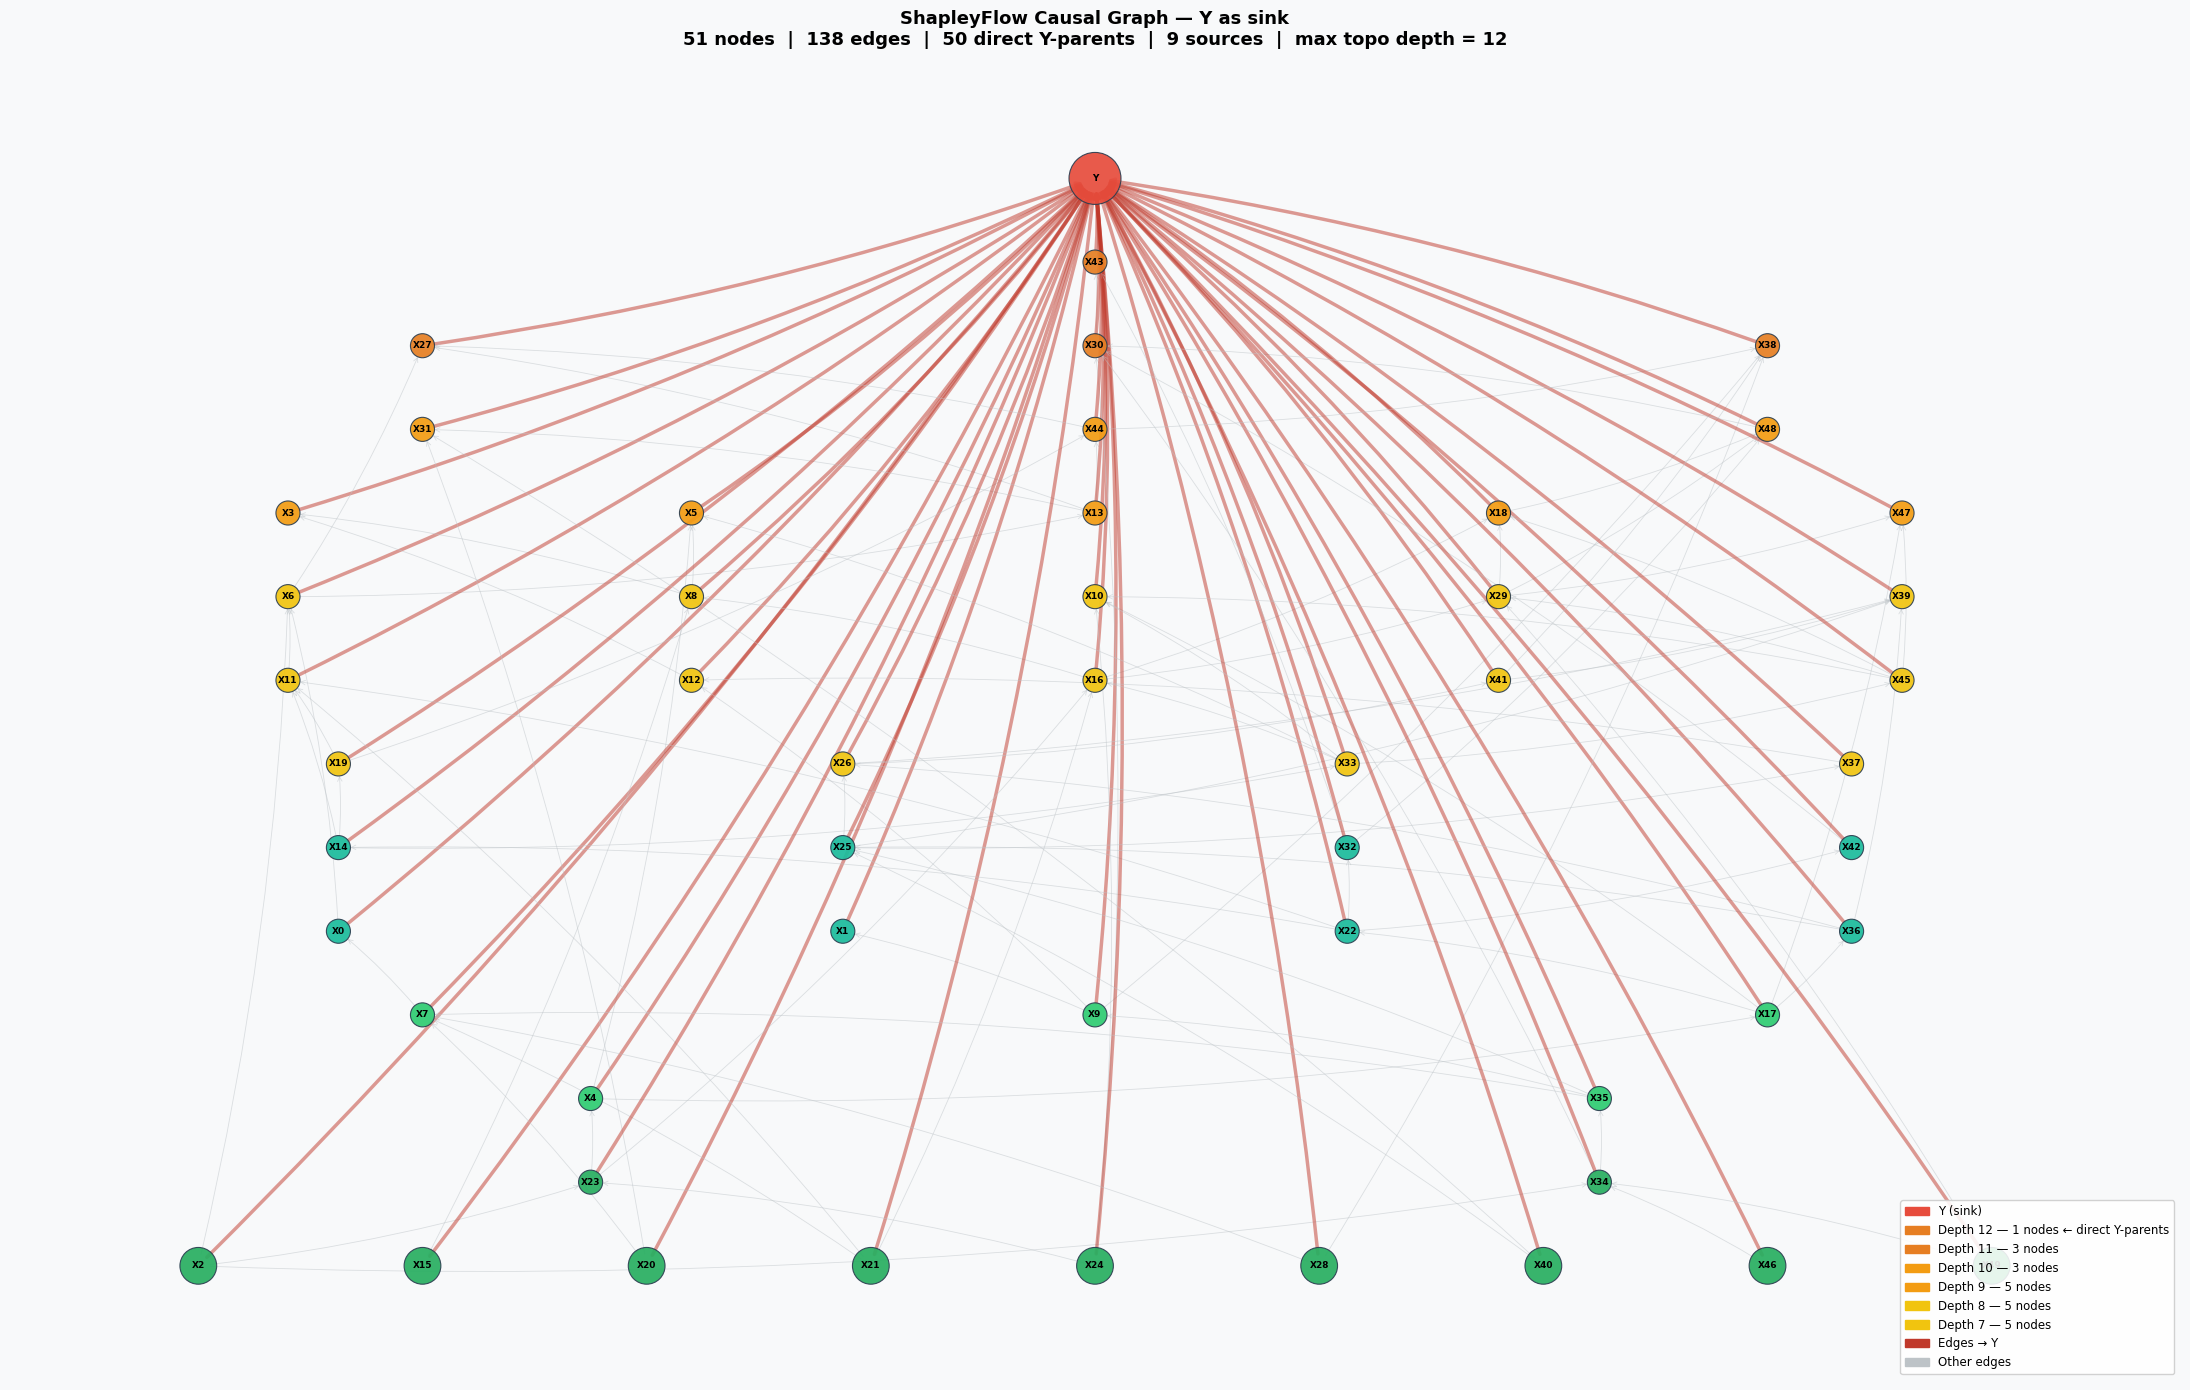

✅ Graph saved to shapflow_causal_graph.png

Topological depth from sources (Y excluded as intermediate):
Depth     Nodes   Edges out (excl Y)    Direct edges →Y
────────────────────────────────────────────────────────
  0           9                   19                  9
  1           2                    4                  2
  2           2                    5                  2
  3           3                    8                  3
  4           4                    8                  4
  5           4                    9                  4
  6           4                    9                  4
  7           5                   11                  5
  8           5                    7                  5
  9           5                    4                  5
  10          3                    3                  3
  11          3                    1                  3
  12          1                    0                  1


In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Build NetworkX graph ──────────────────────────────────────────────────────
G = nx.DiGraph()
fn = feature_names  # includes Y; len = 51
for node_i in flow_explainer.graph_structure:
    G.add_node(node_i, label=fn[node_i])
for u, children in flow_explainer.graph_structure.items():
    for v in children:
        G.add_edge(u, v)

y_idx_v = flow_explainer.y_index
source_set = set(flow_explainer.source_nodes)

# ── Topological depth from sources (ignoring Y as intermediate) ──────────────
# BFS from Y gives every direct Y-parent level 1, hiding structural depth.
# Instead: longest path from any source to each node in the subgraph minus Y.
# Uses Kahn's algorithm (efficient O(V+E)) for longest path in a DAG.
non_y = [n for n in G.nodes() if n != y_idx_v]
children_no_y = {u: [v for v in G.successors(u) if v != y_idx_v] for u in non_y}
parents_no_y  = {v: [] for v in non_y}
for u, ch in children_no_y.items():
    for v in ch:
        parents_no_y[v].append(u)

in_deg = {n: len(parents_no_y[n]) for n in non_y}
topo_depth = {n: 0 for n in non_y}
queue = [n for n in non_y if in_deg[n] == 0]

while queue:
    node = queue.pop(0)
    for child in children_no_y.get(node, []):
        topo_depth[child] = max(topo_depth[child], topo_depth[node] + 1)
        in_deg[child] -= 1
        if in_deg[child] == 0:
            queue.append(child)

max_depth = max(topo_depth.values()) if topo_depth else 0
# Y sits one level above the deepest node (visually at the top)
topo_depth[y_idx_v] = max_depth + 1

# ── Level groups by topo_depth ────────────────────────────────────────────────
all_depths = sorted(set(topo_depth.values()))
level_groups = {d: sorted(nd for nd, dep in topo_depth.items() if dep == d)
                for d in all_depths}

# ── Layout: Y at top, sources at bottom ──────────────────────────────────────
# display_y for depth d = -(max_depth + 1 - d) * Y_STEP
# → Y (d = max_depth+1): display_y = 0  (top)
# → max_depth nodes:    display_y = -Y_STEP
# → sources (d = 0):    display_y = -(max_depth+1)*Y_STEP  (bottom)
Y_STEP   = 2.5
H_SCALE  = 1.4
pos = {}
for d, nodes in level_groups.items():
    n = len(nodes)
    h_gap = max(0.6, H_SCALE * 22 / max(n, 1))
    y_coord = -(max_depth + 1 - d) * Y_STEP
    for k, node in enumerate(nodes):
        pos[node] = ((k - (n - 1) / 2) * h_gap, y_coord)

# ── Colour by proximity to Y (max_depth - topo_depth) ────────────────────────
# proximity 0 (deepest, closest to Y) → orange
# proximity max_depth (sources)       → green
# Y itself                            → red
PROX_PALETTE = ["#e67e22", "#f39c12", "#f1c40f", "#1abc9c", "#2ecc71", "#27ae60"]

def _prox_color(node_idx):
    if node_idx == y_idx_v:
        return "#e74c3c"
    prox = max_depth - topo_depth.get(node_idx, 0)   # 0 = closest to Y
    if max_depth == 0:
        return PROX_PALETTE[0]
    idx = int(round(prox / max_depth * (len(PROX_PALETTE) - 1)))
    return PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]

node_colors = [_prox_color(n) for n in G.nodes()]
node_sizes  = [1400 if n == y_idx_v else (700 if n in source_set else 300)
               for n in G.nodes()]
edge_colors = ["#c0392b" if v == y_idx_v else "#bdc3c7" for u, v in G.edges()]
edge_widths = [2.5 if v == y_idx_v else 0.6 for u, v in G.edges()]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 14))
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
                       alpha=0.5, arrows=True, arrowstyle="->", arrowsize=8,
                       connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       alpha=0.92, linewidths=0.8, edgecolors="#2c3e50")
nx.draw_networkx_labels(G, pos, {n: fn[n] for n in G.nodes()}, ax=ax,
                        font_size=6.5, font_weight="bold")

# ── Legend ────────────────────────────────────────────────────────────────────
n_direct  = sum(1 for u, v in G.edges() if v == y_idx_v)
depth_dist = collections.Counter(topo_depth.values())

legend_entries = [mpatches.Patch(color="#e74c3c", label="Y (sink)")]
for prox in range(min(len(PROX_PALETTE), max_depth + 1)):
    d  = max_depth - prox
    cnt = depth_dist.get(d, 0)
    idx = int(round(prox / max(max_depth, 1) * (len(PROX_PALETTE) - 1)))
    col = PROX_PALETTE[min(idx, len(PROX_PALETTE) - 1)]
    label = (f"Depth {d} — sources ({cnt} nodes)" if d == 0
             else f"Depth {d} — {cnt} nodes" + (" ← direct Y-parents" if d == max_depth else ""))
    legend_entries.append(mpatches.Patch(color=col, label=label))
legend_entries += [
    mpatches.Patch(color="#c0392b", label="Edges → Y"),
    mpatches.Patch(color="#bdc3c7", label="Other edges"),
]
ax.legend(handles=legend_entries, loc="lower right", fontsize=8.5, framealpha=0.88)

ax.set_title(
    f"ShapleyFlow Causal Graph — {fn[y_idx_v]} as sink\n"
    f"{G.number_of_nodes()} nodes  |  {G.number_of_edges()} edges  |  "
    f"{n_direct} direct Y-parents  |  {len(source_set)} sources  |  "
    f"max topo depth = {max_depth}",
    fontsize=13, fontweight="bold", pad=14,
)
ax.axis("off")
plt.tight_layout()
plt.savefig("shapflow_causal_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graph saved to shapflow_causal_graph.png")

# ── Per-depth summary ─────────────────────────────────────────────────────────
print(f"\nTopological depth from sources (Y excluded as intermediate):")
print(f"{'Depth':<8} {'Nodes':>6} {'Edges out (excl Y)':>20} {'Direct edges →Y':>18}")
print("─" * 56)
for d in sorted(set(topo_depth.values())):
    if topo_depth.get(y_idx_v) == d:
        continue
    nodes_d = [nd for nd, dep in topo_depth.items() if dep == d]
    edges_out  = sum(1 for u, v in G.edges() if u in nodes_d and v != y_idx_v)
    edges_to_y = sum(1 for u, v in G.edges() if u in nodes_d and v == y_idx_v)
    print(f"  {d:<6} {len(nodes_d):>6} {edges_out:>20} {edges_to_y:>18}")
